In [2]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import backend as K

import torch
import timm
import joblib


2026-02-10 11:34:55.288228: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770723295.458941     278 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770723295.506741     278 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770723295.920345     278 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770723295.920379     278 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770723295.920382     278 computation_placer.cc:177] computation placer alr

**CELL 2: BASIC Parameters**

In [3]:
IMG_SIZE = 192
BATCH_SIZE = 8
device = "cuda" if torch.cuda.is_available() else "cpu"


**CELL 3: LOAD METADATA (HAM10000)**

In [4]:
meta = pd.read_csv(
    "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
)

labels_df = meta[['image_id', 'dx']]


**CELL 4: IMAGE LOADER (MULTI-FOLDER SAFE)**

In [5]:
def load_images(image_dirs, labels_df):
    images, labels = [], []

    for _, row in labels_df.iterrows():
        for img_dir in image_dirs:
            img_path = os.path.join(img_dir, row['image_id'] + ".jpg")
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                images.append(img)
                labels.append(row['dx'])
                break

    return np.array(images), np.array(labels)


**CELL 5: LOAD IMAGES**

In [6]:
image_dirs = [
    "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1",
    "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2"
]

images, labels = load_images(image_dirs, labels_df)
print(images.shape, labels.shape)


(10015, 192, 192, 3) (10015,)


**CELL 6: LABEL ENCODING**

In [7]:
le = LabelEncoder()
y = le.fit_transform(labels)
print(le.classes_)


['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


**CELL 7: TRAIN–VALIDATION SPLIT(80-20)**

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    images,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

del images
gc.collect()


289

**CELL:8 -  CNN FEATURE EXTRACTOR (EfficientNet)**

In [9]:
cnn_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


I0000 00:00:1770723524.078033     278 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


**CELL 9 — CNN Feature Extraction**

In [10]:
def extract_cnn_features(model, X, batch_size=8):
    feats = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        f = model.predict(batch, verbose=0)
        feats.append(f)
    return np.vstack(feats)

cnn_train = extract_cnn_features(cnn_model, X_train)
cnn_val   = extract_cnn_features(cnn_model, X_val)

print(cnn_train.shape, cnn_val.shape)


I0000 00:00:1770723561.553212     316 service.cc:152] XLA service 0x7fd778003c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770723561.553245     316 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770723562.457168     316 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770723568.286589     316 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


(8012, 1280) (2003, 1280)


****CELL 10-CLEAR CNN FROM MEMORY**

In [11]:
del cnn_model
K.clear_session()
gc.collect()


0

**CELL 11 — Swin Transformer**

In [12]:
swin = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=0
).to(device)

swin.eval()


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

**CELL-12: SWIM FEATURE EXTRACTION**

In [13]:
def extract_swin_features(model, X, batch_size=4):
    feats = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        resized = np.array([cv2.resize(img, (224,224)) for img in batch])
        tensor = torch.tensor(resized).permute(0,3,1,2).float().to(device)

        with torch.no_grad():
            f = model(tensor).cpu().numpy()
        feats.append(f)

    return np.vstack(feats)

swin_train = extract_swin_features(swin, X_train)
swin_val   = extract_swin_features(swin, X_val)

print(swin_train.shape, swin_val.shape)


(8012, 768) (2003, 768)


**🟢 STEP 13 — HANDCRAFTED FEATURES (FINAL, FIXED)**

In [14]:
from skimage.feature import graycomatrix, graycoprops

def handcrafted(img):
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    features = []
    for prop in ['contrast', 'energy', 'homogeneity', 'correlation']:
        features.extend(graycoprops(glcm, prop)[0])

    return features  # 16


**🟢 STEP 14 — HANDCRAFTED FEATURE EXTRACTION**

In [15]:
hc_train = np.array([handcrafted(img) for img in X_train])
hc_val   = np.array([handcrafted(img) for img in X_val])

print(hc_train.shape, hc_val.shape)


(8012, 16) (2003, 16)


**🟢 STEP 15 — FEATURE FUSION (2064 FEATURES)**

In [16]:
X_train_fused = np.concatenate([cnn_train, swin_train, hc_train], axis=1)
X_val_fused   = np.concatenate([cnn_val, swin_val, hc_val], axis=1)

print(X_train_fused.shape, X_val_fused.shape)


(8012, 2064) (2003, 2064)


**🟢 STEP 16 — SCALING (NEW SCALER)**

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fused)
X_val_scaled   = scaler.transform(X_val_fused)


**STEP17: SMOTE**

In [18]:
pca = PCA(n_components=0.97, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)

print(X_train_pca.shape, X_val_pca.shape)


(8012, 282) (2003, 282)


**CELL-18 : PCA**

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

print(X_train_smote.shape)


(37548, 282)


**🟢 CELL 19 — LIGHTGBM TRAINING (CORRECT)**

In [20]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multiclass",
    class_weight="balanced",
    random_state=42,
    force_col_wise=True,
    n_jobs=-1
)

lgbm.fit(X_train_smote, y_train_smote)


[LightGBM] [Info] Total Bins 71910
[LightGBM] [Info] Number of data points in the train set: 37548, number of used features: 282
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               force_col_wise=True, learning_rate=0.05, max_depth=8,
               n_estimators=300, n_jobs=-1, objective='multiclass',
               random_state=42, subsample=0.8)

In [21]:
print("Model expects:", lgbm.n_features_in_)
print("Validation has:", X_val_pca.shape[1])

y_pred_lgbm = lgbm.predict(X_val_pca)

print("LightGBM Accuracy:", accuracy_score(y_val, y_pred_lgbm))
print(classification_report(y_val, y_pred_lgbm, target_names=le.classes_))


Model expects: 282
Validation has: 282
LightGBM Accuracy: 0.7683474787818273
              precision    recall  f1-score   support

       akiec       0.52      0.37      0.43        65
         bcc       0.59      0.52      0.55       103
         bkl       0.57      0.61      0.59       220
          df       0.75      0.13      0.22        23
         mel       0.46      0.41      0.43       223
          nv       0.86      0.91      0.89      1341
        vasc       1.00      0.43      0.60        28

    accuracy                           0.77      2003
   macro avg       0.68      0.48      0.53      2003
weighted avg       0.76      0.77      0.76      2003



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [22]:
joblib.dump(lgbm, "lgbm_skin_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']

**CELL 11-TRAIN XGBOOST**

In [23]:
num_classes = len(np.unique(y_train))

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=7, ...)

**STEP 20 — EVALUATION (INTERNAL VALIDATION)**

In [24]:
y_pred = xgb.predict(X_val_pca)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=le.classes_))


Accuracy: 0.7678482276585122
              precision    recall  f1-score   support

       akiec       0.50      0.45      0.47        65
         bcc       0.50      0.54      0.52       103
         bkl       0.57      0.57      0.57       220
          df       0.75      0.26      0.39        23
         mel       0.47      0.47      0.47       223
          nv       0.88      0.90      0.89      1341
        vasc       0.83      0.54      0.65        28

    accuracy                           0.77      2003
   macro avg       0.64      0.53      0.57      2003
weighted avg       0.77      0.77      0.76      2003



In [25]:
print(type(lgbm))
print(type(scaler))
print(type(pca))
print(type(le))
print(type(xgb))


<class 'lightgbm.sklearn.LGBMClassifier'>
<class 'sklearn.preprocessing._data.StandardScaler'>
<class 'sklearn.decomposition._pca.PCA'>
<class 'sklearn.preprocessing._label.LabelEncoder'>
<class 'xgboost.sklearn.XGBClassifier'>


**SAVE BOTH MODELS**

In [26]:
import joblib

# Save XGBoost
joblib.dump(xgb, "xgb_skin_cancer_model.pkl")

# Save LightGBM
joblib.dump(lgbm, "lgbm_skin_cancer_model.pkl")

# Save preprocessing
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(le, "label_encoder.pkl")

print("All models saved")


All models saved


In [27]:
import os
os.listdir(".")


['label_encoder.pkl',
 '.virtual_documents',
 'xgb_skin_cancer_model.pkl',
 'lgbm_skin_cancer_model.pkl',
 'pca.pkl',
 'scaler.pkl']

**TEST PREDICTIONS (XGBOOST vs LIGHTGBM)**

In [28]:
def predict_image(img, model):
    # ---- CNN features ----
    cnn_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    cnn_feat = cnn_model.predict(img[np.newaxis, ...], verbose=0)

    # ---- Swin features ----
    img_224 = cv2.resize(img, (224,224))
    img_tensor = torch.tensor(img_224)\
        .permute(2,0,1)\
        .unsqueeze(0)\
        .float()\
        .to(device)

    with torch.no_grad():
        swin_feat = swin(img_tensor).cpu().numpy()

    # ---- Handcrafted ----
    hc_feat = np.array(handcrafted(img)).reshape(1,-1)

    # ---- Fusion ----
    fused = np.concatenate([cnn_feat, swin_feat, hc_feat], axis=1)

    # ---- Preprocessing ----
    fused_scaled = scaler.transform(fused)
    fused_pca = pca.transform(fused_scaled)

    # ---- Prediction ----
    pred = model.predict(fused_pca)
    label = le.inverse_transform(pred)[0]

    return label


**TEST ON HAM10000 (KNOWN LABEL)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


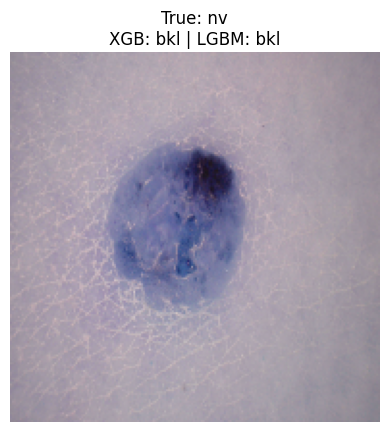

In [29]:
idx = np.random.randint(0, len(X_val))

img = X_val[idx]
true_label = le.inverse_transform([y_val[idx]])[0]

pred_xgb  = predict_image(img, xgb)
pred_lgbm = predict_image(img, lgbm)

plt.imshow(img)
plt.title(f"True: {true_label}\nXGB: {pred_xgb} | LGBM: {pred_lgbm}")
plt.axis("off")
plt.show()


In [30]:
import os

BASE_ISIC_PATH = "/kaggle/input/isic-2019-skin-lesion-images-for-classification"
os.listdir(BASE_ISIC_PATH)


['MEL',
 'VASC',
 'SCC',
 'DF',
 'NV',
 'ISIC_2019_Training_GroundTruth.csv',
 'ISIC_2019_Training_Metadata.csv',
 'BKL',
 'BCC',
 'AK']

**TEST ON ISIC (EXTERNAL VALIDATION)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


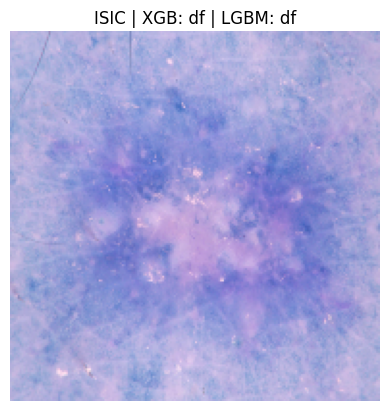

In [31]:
isic_path = "/kaggle/input/isic-2019-skin-lesion-images-for-classification/DF/ISIC_0025223.jpg"
# change filename to one that exists

isic_img = cv2.imread(isic_path)
isic_img = cv2.resize(isic_img, (IMG_SIZE, IMG_SIZE))
isic_img = isic_img / 255.0

pred_xgb  = predict_image(isic_img, xgb)
pred_lgbm = predict_image(isic_img, lgbm)

plt.imshow(isic_img)
plt.title(f"ISIC | XGB: {pred_xgb} | LGBM: {pred_lgbm}")
plt.axis("off")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


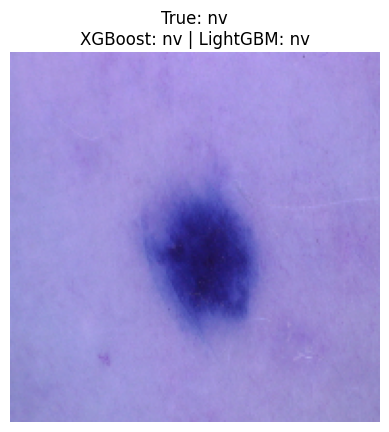

In [32]:
idx = np.random.randint(0, len(X_val))
img = X_val[idx]
true_label = le.inverse_transform([y_val[idx]])[0]

pred_xgb  = predict_image(img, xgb)
pred_lgbm = predict_image(img, lgbm)

plt.imshow(img)
plt.title(
    f"True: {true_label}\n"
    f"XGBoost: {pred_xgb} | LightGBM: {pred_lgbm}"
)
plt.axis("off")
plt.show()


In [ ]:
##################################################OPTION 1 — SHOW 20% TEST PREDICTIONS IN NOTEBOOK (BEST FOR REVIEW)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


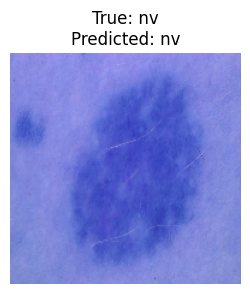

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


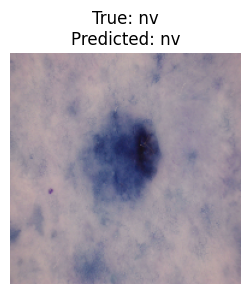

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


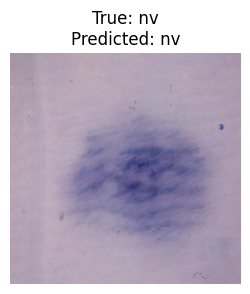

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


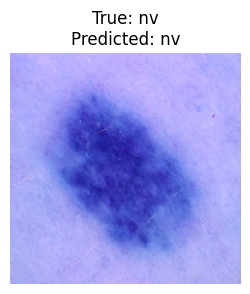

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


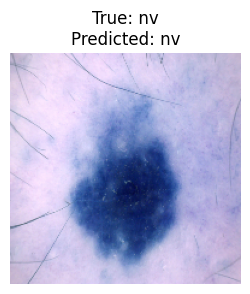

In [33]:
import random

num_samples = 5  # you can show 5–10 images
indices = random.sample(range(len(X_val)), num_samples)

for idx in indices:
    img = X_val[idx]
    true_label = le.inverse_transform([y_val[idx]])[0]
    pred_label = predict_image(img, lgbm)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPredicted: {pred_label}")
    plt.axis("off")
    plt.show()


#########################OPTION 2 — SHOW CONFUSION MATRIX (VERY IMPRESSIVE)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


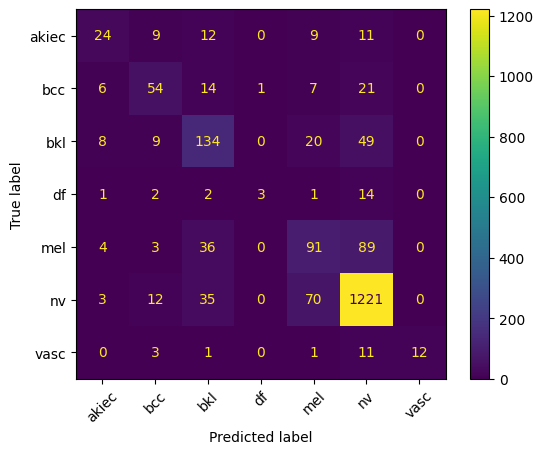

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = lgbm.predict(X_val_pca)

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.show()


## IMP 




In [36]:
import joblib
import os

SAVE_DIR = "/kaggle/working"

joblib.dump(xgb,  os.path.join(SAVE_DIR, "xgb_skin_cancer_model.pkl"))
joblib.dump(lgbm, os.path.join(SAVE_DIR, "lgbm_skin_cancer_model.pkl"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))
joblib.dump(pca, os.path.join(SAVE_DIR, "pca.pkl"))
joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

print("Models saved to /kaggle/working")
print(os.listdir(SAVE_DIR))

Models saved to /kaggle/working
['scaler.pkl', 'lgbm_skin_cancer_model.pkl', '.virtual_documents', 'label_encoder.pkl', 'pca.pkl', 'xgb_skin_cancer_model.pkl']


In [37]:
!zip /kaggle/working/skin_cancer_models.zip \
    /kaggle/working/xgb_skin_cancer_model.pkl \
    /kaggle/working/lgbm_skin_cancer_model.pkl \
    /kaggle/working/scaler.pkl \
    /kaggle/working/pca.pkl \
    /kaggle/working/label_encoder.pkl


  adding: kaggle/working/xgb_skin_cancer_model.pkl (deflated 65%)
  adding: kaggle/working/lgbm_skin_cancer_model.pkl (deflated 56%)
  adding: kaggle/working/scaler.pkl (deflated 5%)
  adding: kaggle/working/pca.pkl (deflated 4%)
  adding: kaggle/working/label_encoder.pkl (deflated 37%)


## ALWAYS RUN THESE CELLS TO CONTINUE WORK

In [19]:
import os

MODEL_DIR = "/kaggle/input/models/ramyalingampalli/skin-cancer-models/other/default/1/kaggle/working"
print(os.listdir(MODEL_DIR))


['label_encoder.pkl', 'xgb_skin_cancer_model.pkl', 'lgbm_skin_cancer_model.pkl', 'scaler.pkl', 'pca.pkl']


In [20]:
import joblib

MODEL_DIR = "/kaggle/input/models/ramyalingampalli/skin-cancer-models/other/default/1/kaggle/working"

xgb    = joblib.load(f"{MODEL_DIR}/xgb_skin_cancer_model.pkl")
lgbm   = joblib.load(f"{MODEL_DIR}/lgbm_skin_cancer_model.pkl")
scaler = joblib.load(f"{MODEL_DIR}/scaler.pkl")
pca    = joblib.load(f"{MODEL_DIR}/pca.pkl")
le     = joblib.load(f"{MODEL_DIR}/label_encoder.pkl")

print("✅ Models loaded successfully — ready to continue work")


✅ Models loaded successfully — ready to continue work


## SCORE-CAM IMPLEMENTATION

**STEP 1 — CNN MODEL FOR CAM (same as before**

In [37]:
# ==============================
# GLOBAL CONFIG (REQUIRED)
# ==============================
IMG_SIZE = 192   # MUST match training size


In [38]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

num_classes = len(le.classes_)

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(num_classes, activation="softmax")(x)

scorecam_model = Model(inputs=base_model.input, outputs=output)


**STEP 2 — SCORE-CAM FUNCTION (CORE)**

In [39]:
def compute_scorecam(model, img_array, class_idx, layer_name):
    cam_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(layer_name).output,
            model.output
        ]
    )

    conv_outputs, predictions = cam_model(img_array)
    conv_outputs = conv_outputs[0].numpy()  # (H, W, C)

    scorecam = np.zeros(conv_outputs.shape[:2], dtype=np.float32)

    for i in range(conv_outputs.shape[-1]):
        fmap = conv_outputs[:, :, i]
        fmap = np.maximum(fmap, 0)

        if np.max(fmap) == 0:
            continue

        fmap_norm = fmap / np.max(fmap)
        fmap_resized = cv2.resize(fmap_norm, (IMG_SIZE, IMG_SIZE))

        masked_img = img_array[0] * fmap_resized[..., np.newaxis]
        masked_img = np.expand_dims(masked_img, axis=0)

        score = model.predict(masked_img, verbose=0)[0][class_idx]
        scorecam += score * fmap

    scorecam = np.maximum(scorecam, 0)
    scorecam = scorecam / np.max(scorecam)

    return scorecam


**STEP 3 — APPLY SCORE-CAM ON TEST IMAGE**

In [71]:
import cv2
import numpy as np

# 🔹 give path to ANY image (HAM or ISIC)
img_path = "/kaggle/input/isic-2019-skin-lesion-images-for-classification/VASC/ISIC_0025873.jpg"
# OR ISIC:
# img_path = "/kaggle/input/isic-2019-skin-lesion-images-for-classification/NV/ISIC_0000000.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0

img_input = np.expand_dims(img, axis=0)


In [48]:
scorecam = compute_scorecam(
    scorecam_model,
    img_input,
    pred_class,
    layer_name="block6a_expand_conv"
)



**✅ Step-4Visualize Score-CAM**


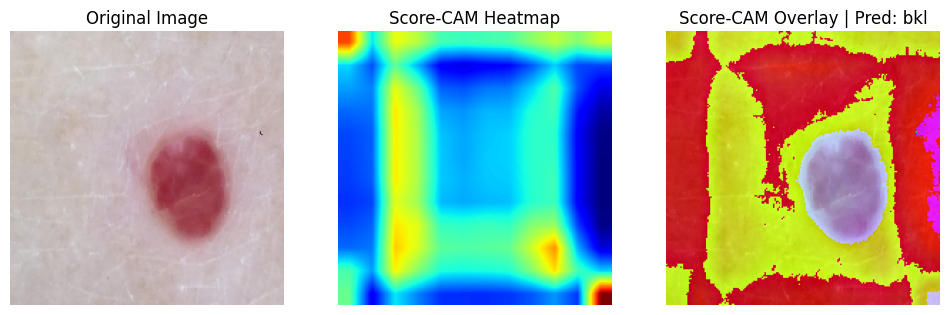

In [72]:
scorecam_resized = cv2.resize(scorecam, (IMG_SIZE, IMG_SIZE))
heatmap = cv2.applyColorMap(
    np.uint8(255 * scorecam_resized),
    cv2.COLORMAP_JET
)

overlay = heatmap * 0.4 + (img * 255)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(scorecam_resized, cmap="jet")
plt.title("Score-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay.astype(np.uint8))
plt.title(f"Score-CAM Overlay | Pred: {pred_label}")
plt.axis("off")

plt.show()


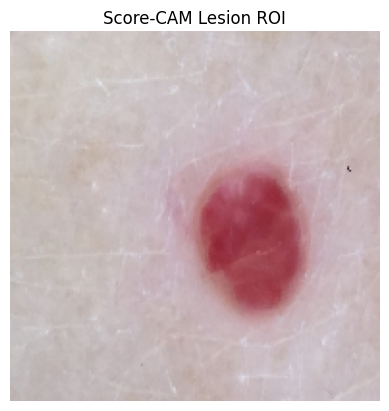

In [73]:
threshold = 0.5
binary_mask = scorecam_resized > threshold

contours, _ = cv2.findContours(
    np.uint8(binary_mask),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) > 0:
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    lesion_roi = img[y:y+h, x:x+w]

    plt.imshow(lesion_roi)
    plt.title("Score-CAM Lesion ROI")
    plt.axis("off")
    plt.show()


#####################################################################################################################

## GRAD-CAM FOR EXPLAINABILITY

**CELL 1: Build CNN + classifier head (for Grad-CAM only)**

In [21]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0

IMG_SIZE = 192
num_classes = len(le.classes_)  # your label encoder

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(num_classes, activation="softmax")(x)

gradcam_model = Model(inputs=base_model.input, outputs=output)

#✅ Now model produces class probabilities
#✅ Grad-CAM will work


**CELL 2: Correct Grad-CAM function (SAFE)**

In [22]:
def grad_cam(model, img_array, layer_name):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy(), int(class_idx)


**CELL 3: Load image**

In [23]:
img_path = "/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024306.jpg"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0

img_input = np.expand_dims(img, axis=0)


**CELL 4: Generate Grad-CAM heatmap (FIXED)**

In [24]:
heatmap, pred_class = grad_cam(
    gradcam_model,
    img_input,
    layer_name="block6a_expand_conv"
)

pred_label = le.inverse_transform([pred_class])[0]
print("Predicted class:", pred_label)


Predicted class: bcc


**CELL 5: Visualization (NO ERROR)**

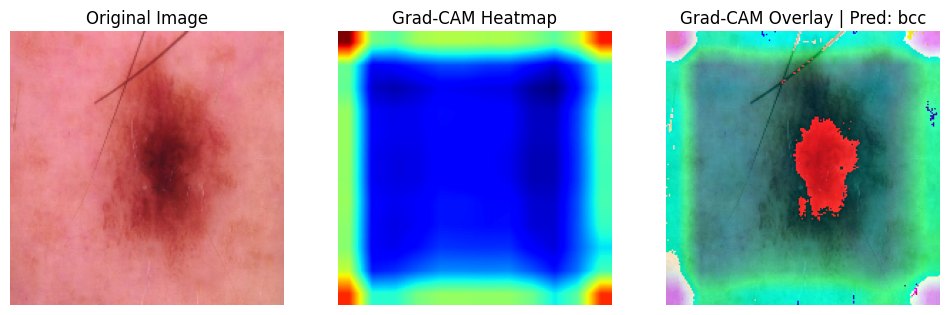

In [25]:
heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

overlay = heatmap_color * 0.4 + (img * 255)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay.astype(np.uint8))
plt.title(f"Grad-CAM Overlay | Pred: {pred_label}")
plt.axis("off")

plt.show()


## SHAP EXPLAINABILITY (FOR XGBOOST / LIGHTGBM)

In [35]:
required_objects = ["xgb", "X_train_pca", "X_val_pca"]

for obj in required_objects:
    if obj in globals():
        print(f"✅ {obj} exists")
    else:
        print(f"❌ {obj} NOT found")


✅ xgb exists
✅ X_train_pca exists
✅ X_val_pca exists


In [36]:
print("X_train_pca shape:", X_train_pca.shape)
print("X_val_pca shape:", X_val_pca.shape)


X_train_pca shape: (8012, 282)
X_val_pca shape: (2003, 282)


**STEP 1: INSTALL & IMPORT SHAP**

In [61]:
import shap
import numpy as np
import matplotlib.pyplot as plt


In [62]:
def xgb_predict(data):
    return xgb.predict_proba(data)


In [63]:
X_background = X_train_pca[:100]


In [64]:
explainer = shap.Explainer(
    xgb_predict,
    X_background
)


In [65]:
X_shap = X_val_pca[:200]


In [67]:
shap_values = explainer(
    X_shap,
    max_evals=600   # MUST be >= 2 * num_features + 1
)


PermutationExplainer explainer: 201it [08:25,  2.55s/it]                         


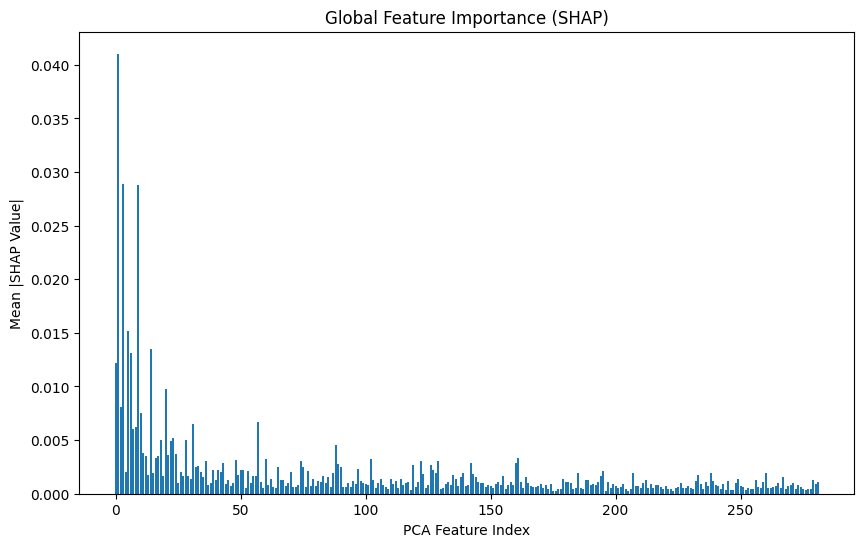

In [69]:
# Convert to numpy (samples × features × classes)
shap_array = shap_values.values

# Average absolute SHAP across samples & classes
mean_shap = np.mean(np.abs(shap_array), axis=(0, 2))

# Plot manually (robust, no SHAP bug)
plt.figure(figsize=(10,6))
plt.bar(range(len(mean_shap)), mean_shap)
plt.title("Global Feature Importance (SHAP)")
plt.xlabel("PCA Feature Index")
plt.ylabel("Mean |SHAP Value|")
plt.show()


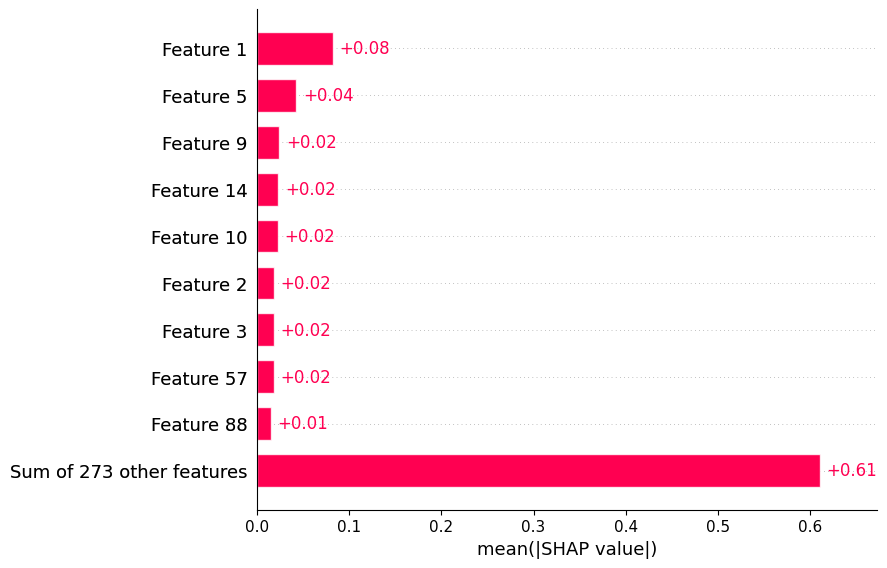

In [70]:
class_idx = list(le.classes_).index("mel")

shap.plots.bar(
    shap.Explanation(
        values=shap_values.values[:,:,class_idx],
        base_values=shap_values.base_values[:,class_idx],
        data=X_shap
    )
)
